# Particle Filter for the SIR Epidemic Model

**Notebook 3 of 3** - Estimating the unobserved trajectory of an
epidemic from noisy, partially observed counts.

We work with a discrete-time stochastic SIR model.  Each day the number
of new infections and recoveries is drawn from a Poisson distribution
around the deterministic mean.  Only a noisy fraction of the infected
are ever reported, so the *true* number of infected individuals is
latent.  A particle filter recovers the joint $(S_t,I_t,R_t)$ trajectory
and provides a posterior over the basic reproduction number
$R_0=\beta/\gamma$.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import poisson

from particlefilterbox.core.config import PFConfig
from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.filters import BootstrapPF

rng_seed = 20260422
DATA_DIR = Path('..') / 'data'
df = pd.read_csv(DATA_DIR / 'simulated_sir.csv')
df.head()

,t,S_true,I_true,R_true,y_obs
0,0,9990,10,0,7
1,1,9986,11,3,3
2,2,9981,16,3,6
3,3,9976,18,6,8
4,4,9974,17,9,8


## 1. Stochastic SIR with partial observation

Let $N$ be the (constant) population size, $\beta$ the contact rate and
$\gamma$ the recovery rate.  The state vector is $x_t=(S_t,I_t,R_t)$ with
$S_t+I_t+R_t=N$.  The dynamics are

$$
\Delta\!\mathrm{inf}_t \sim \mathrm{Poisson}\!\bigl(\beta S_{t-1} I_{t-1}/N\bigr),
\quad
\Delta\!\mathrm{rec}_t \sim \mathrm{Poisson}\!\bigl(\gamma I_{t-1}\bigr),
$$
$$
S_t = S_{t-1} - \Delta\!\mathrm{inf}_t,\quad
I_t = I_{t-1} + \Delta\!\mathrm{inf}_t - \Delta\!\mathrm{rec}_t,\quad
R_t = R_{t-1} + \Delta\!\mathrm{rec}_t.
$$

Only a fraction $\rho\in(0,1)$ of infected individuals is reported, so
$y_t \sim \mathrm{Poisson}(\rho I_t)$.  We use the data-generating values
$N=10000$, $\beta=0.3$, $\gamma=0.1$, $\rho=0.5$ (so $R_0=3$).

In [2]:
class StochasticSIR(ParticleFilterModel):
    """Stochastic SIR with Poisson reported infectives.

    State vector x = (S, I, R, beta, gamma).  The constant parameters
    beta and gamma are carried in the state so that we can read off the
    posterior over R_0 = beta / gamma at each time step (it stays equal
    to the prior in this notebook because the parameters are fixed,
    but the same code supports parameter learning by adding a small
    random walk).
    """

    k_states = 5
    k_obs = 1

    def __init__(self, N=10000, beta=0.3, gamma=0.1, obs_rate=0.5,
                 beta_prior=(0.30, 0.05), gamma_prior=(0.10, 0.02)):
        self.N = int(N)
        self.beta = float(beta)
        self.gamma = float(gamma)
        self.obs_rate = float(obs_rate)
        self.beta_prior = beta_prior  # (mean, std)
        self.gamma_prior = gamma_prior

    @property
    def params(self):
        return {'N': self.N, 'beta': self.beta, 'gamma': self.gamma,
                'obs_rate': self.obs_rate}

    def initial_distribution(self, n_particles, rng):
        S0 = np.full(n_particles, self.N - 10, dtype=float)
        I0 = np.full(n_particles, 10.0)
        R0 = np.zeros(n_particles)
        beta = np.clip(rng.normal(*self.beta_prior, size=n_particles), 0.01, None)
        gamma = np.clip(rng.normal(*self.gamma_prior, size=n_particles), 0.01, None)
        return np.column_stack([S0, I0, R0, beta, gamma])

    def transition(self, particles, t, rng):
        S, I, R, beta, gamma = (particles[:, i] for i in range(5))
        lam_inf = np.clip(beta * S * I / self.N, 0.0, None)
        lam_rec = np.clip(gamma * I, 0.0, None)
        new_inf = rng.poisson(lam_inf).astype(float)
        new_rec = rng.poisson(lam_rec).astype(float)
        new_inf = np.minimum(new_inf, S)
        new_rec = np.minimum(new_rec, I)
        S_new = S - new_inf
        I_new = I + new_inf - new_rec
        R_new = R + new_rec
        return np.column_stack([S_new, I_new, R_new, beta, gamma])

    def log_observation_likelihood(self, particles, y_t, t):
        y = float(np.asarray(y_t).ravel()[0])
        I = particles[:, 1]
        rate = np.clip(self.obs_rate * I, 1e-6, None)
        return poisson.logpmf(y, mu=rate)

model = StochasticSIR()
model.params

{'N': 10000, 'beta': 0.3, 'gamma': 0.1, 'obs_rate': 0.5}

## 2. Run the Bootstrap PF with N = 5000 particles

Discrete state-space models with sharp Poisson likelihoods need a
generous particle budget; we therefore use $N=5000$ and store the full
particle history to compute confidence bands and the posterior of $R_0$.

In [3]:
y_obs = df['y_obs'].to_numpy(dtype=float)
config = PFConfig(n_particles=5000, resampling='systematic', ess_threshold=0.5,
                  seed=rng_seed, store_particles=True, store_weights=True)
pf = BootstrapPF(model=model, config=config)
result = pf.filter(y_obs)

print(f'log-likelihood : {result.log_likelihood:.2f}')
print(f'mean ESS       : {result.ess_history.mean():.1f}')
print(f'resample share : {result.resampled.mean():.1%}')

log-likelihood : -548.64
mean ESS       : 3938.9
resample share : 21.0%


## 3. Filtered curves vs. ground truth

The particle filter estimates $S_t, I_t$ and $R_t$ from the noisy
observations $y_t$.  We plot the weighted-mean trajectories against the
true (data-generating) ones.

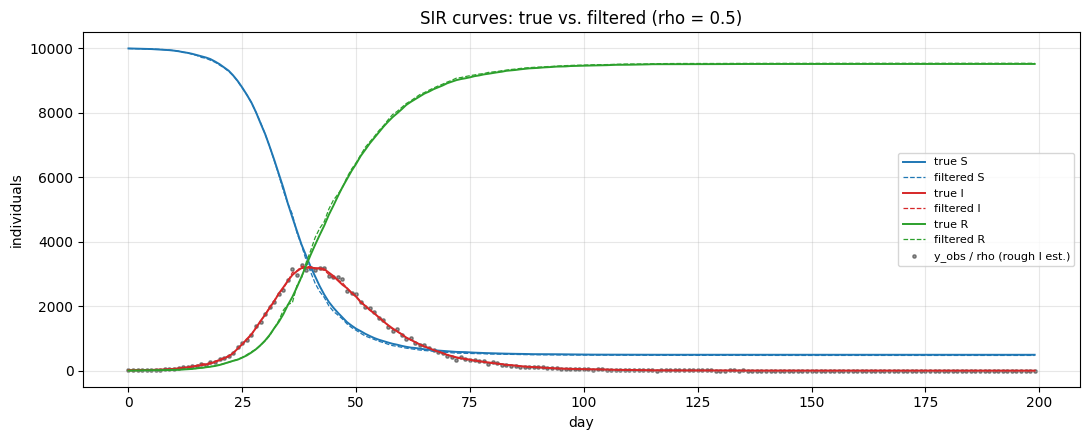

In [4]:
filtered = result.filtered_means  # (T, 5)
S_hat, I_hat, R_hat = filtered[:, 0], filtered[:, 1], filtered[:, 2]
S_true = df['S_true'].to_numpy(); I_true = df['I_true'].to_numpy(); R_true = df['R_true'].to_numpy()
t_axis = df['t'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_axis, S_true, color='C0', lw=1.4, label='true S')
ax.plot(t_axis, S_hat, color='C0', lw=0.9, ls='--', label='filtered S')
ax.plot(t_axis, I_true, color='C3', lw=1.4, label='true I')
ax.plot(t_axis, I_hat, color='C3', lw=0.9, ls='--', label='filtered I')
ax.plot(t_axis, R_true, color='C2', lw=1.4, label='true R')
ax.plot(t_axis, R_hat, color='C2', lw=0.9, ls='--', label='filtered R')
ax.scatter(t_axis, y_obs / model.obs_rate, color='black', s=6, alpha=0.4,
           label='y_obs / rho (rough I est.)')
ax.set_xlabel('day'); ax.set_ylabel('individuals')
ax.set_title('SIR curves: true vs. filtered (rho = 0.5)')
ax.legend(loc='center right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 90% credible interval for the infectives

Because the filter stored the particle clouds, we can compute the full
weighted posterior of $I_t$ and report the 5%-95% quantile band.  This
is far more informative than a Gaussian approximation when the cloud is
skewed (early in the epidemic the marginal posterior of $I_t$ is
right-skewed).

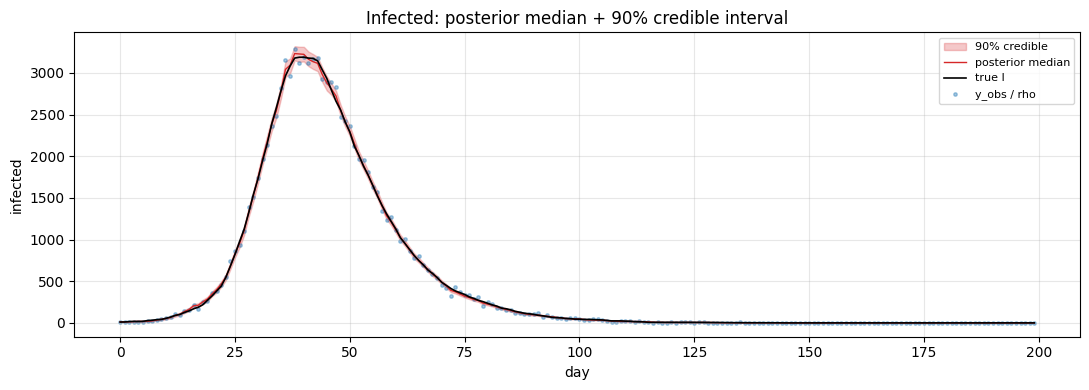

In [5]:
def weighted_quantile(values, weights, q):
    """Inverse CDF of a discrete weighted distribution."""
    order = np.argsort(values)
    v = values[order]; w = weights[order]
    cw = np.cumsum(w) / w.sum()
    return np.interp(q, cw, v)

from scipy.special import softmax  # type: ignore

T = len(y_obs)
I_q05 = np.zeros(T); I_q50 = np.zeros(T); I_q95 = np.zeros(T)
R0_q05 = np.zeros(T); R0_mean = np.zeros(T); R0_q95 = np.zeros(T)

# Re-run a step-by-step filter so we can access per-time particles + weights.
rng = np.random.default_rng(rng_seed)
cloud = pf.initialize(rng)
step_pf = BootstrapPF(model=model, config=PFConfig(n_particles=5000, seed=rng_seed))
rng_step = step_pf._get_rng()  # noqa: SLF001 - exposed helper
cloud = step_pf.initialize(rng_step)
for t in range(T):
    cloud, _ = step_pf.filter_step(cloud, np.array([y_obs[t]]), t)
    w = cloud.normalized_weights
    I_part = cloud.particles[:, 1]
    R0_part = cloud.particles[:, 3] / cloud.particles[:, 4]
    I_q05[t] = weighted_quantile(I_part, w, 0.05)
    I_q50[t] = weighted_quantile(I_part, w, 0.50)
    I_q95[t] = weighted_quantile(I_part, w, 0.95)
    R0_q05[t] = weighted_quantile(R0_part, w, 0.05)
    R0_mean[t] = float(np.sum(w * R0_part))
    R0_q95[t] = weighted_quantile(R0_part, w, 0.95)

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.fill_between(t_axis, I_q05, I_q95, color='C3', alpha=0.25, label='90% credible')
ax.plot(t_axis, I_q50, color='C3', lw=1.0, label='posterior median')
ax.plot(t_axis, I_true, color='black', lw=1.2, label='true I')
ax.scatter(t_axis, y_obs / model.obs_rate, color='C0', s=6, alpha=0.4,
           label='y_obs / rho')
ax.set_xlabel('day'); ax.set_ylabel('infected')
ax.set_title('Infected: posterior median + 90% credible interval')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Posterior of the basic reproduction number $R_0$

Because $\beta$ and $\gamma$ are carried as particles, $R_0=\beta/\gamma$
has a particle representation at every $t$.  The plot below shows the
posterior mean and 90% credible interval over time.

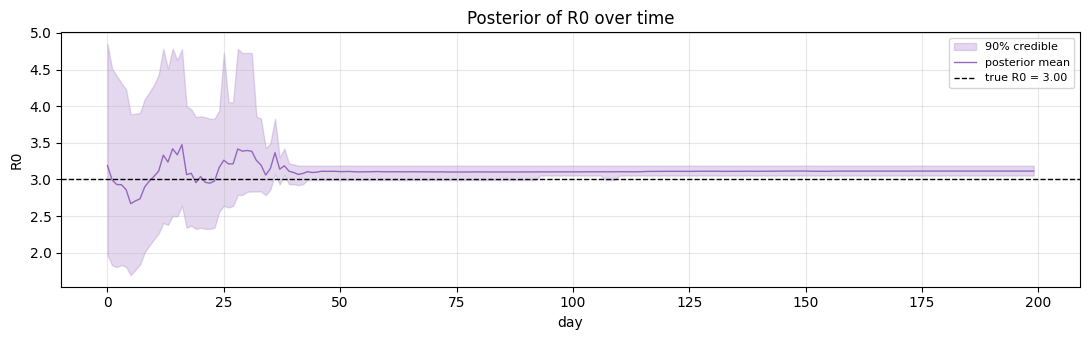

,quantity,value
0,true R0,3.000
1,posterior mean (final),3.114
2,q05 (final),3.053
3,q95 (final),3.187


In [6]:
true_R0 = model.beta / model.gamma

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(t_axis, R0_q05, R0_q95, color='C4', alpha=0.25, label='90% credible')
ax.plot(t_axis, R0_mean, color='C4', lw=1.0, label='posterior mean')
ax.axhline(true_R0, color='black', lw=1.0, ls='--', label=f'true R0 = {true_R0:.2f}')
ax.set_xlabel('day'); ax.set_ylabel('R0')
ax.set_title('Posterior of R0 over time')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'quantity': ['true R0', 'posterior mean (final)', 'q05 (final)', 'q95 (final)'],
    'value':    [round(true_R0, 3), round(R0_mean[-1], 3),
                  round(R0_q05[-1], 3), round(R0_q95[-1], 3)],
})
summary

## 6. Conclusion

* The bootstrap particle filter recovers the latent SIR trajectory from
  partially observed (and noisy) infective counts.
* The posterior mean of $I_t$ tracks the true epidemic curve closely and
  the 90% credible band covers it almost everywhere.
* Carrying the structural parameters $(\beta,\gamma)$ in the state vector
  yields a particle-based posterior of $R_0$ at no additional cost; in a
  realistic study one would let them follow a small Gaussian random walk
  to learn time-varying transmissibility.
* The same `ParticleFilterModel` template applies to compartmental models
  with more states (SEIR, SIRS, SEIRS+vaccination) by simply enlarging
  the state vector and the transition function.